<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%208/W08_L1_Attention_in_Vision_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=gYACi7Tq1y4) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%208/NPTEL_Jul24_DL4CV_W08_P01.pdf)

In [1]:
# Week 8, Lecture 1: Attention in Vision Models
from IPython.display import HTML, display

VIDEO_ID = "gYACi7Tq1y4"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 8, Lecture 1: Attention Models in Vision — An Introduction

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§8.1 Attention Models in Vision**.

**What you will learn**

- Why a fixed-length context vector is an **information bottleneck**, and what breaks because of it.
- The attention mechanism: $c_t = \sum_j \alpha_{t,j} h_j$ with $\alpha$ a softmax over source positions.
- Six alignment score functions, implemented and compared — including which are equivalent to which.
- How the same machinery moves from **time-steps** to **space-steps** for images.
- Hard versus soft, global versus local, and self-attention.

**Contents**

1. The encoder-decoder bottleneck
2. The attention mechanism
3. Alignment score functions
4. From time-steps to space-steps
5. Modes of attention
6. Explore and verify

**How to run**  Everything is tiny and runs in seconds on **Colab CPU or GPU** (no GPU needed). Run the setup cell first, then go top to bottom.

## Review

Week 7 built RNNs, trained them with backpropagation through time, and fixed the vanishing
gradient with the gated additive states of LSTMs and GRUs. That gives a decoder a hidden
state, but in an encoder-decoder model the decoder still has to work from **one** vector
summarising the entire input. This lecture is about why that fails and what replaces it.

## Setup

In [2]:
# Run this cell first. Works on Colab (CPU or GPU) and locally.
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_printoptions(precision=4, sci_mode=False)
print('torch', torch.__version__, '| device:', device)

torch 2.8.0 | device: cpu


## 1. The encoder-decoder bottleneck

An encoder-decoder model compresses the whole input — a sentence, an image, a video — into
a **context vector of fixed length**, and the decoder generates from that alone.

The hidden state $h_t$ is a compressed form of all previous inputs $(x_1, \dots, x_t)$. But
if the input is long, can $h_T$ really encode everything without forgetting? That is the
**information bottleneck**, and it shows up as a characteristic failure: BLEU score rises
with sentence length up to a point, then **degrades** for long sentences, while the expected
curve would simply saturate.

In [3]:
# A fixed-length vector has finite capacity. Pack more independent items into it and
# retrieval gets worse, however the encoder is built.
d = 32                                        # context vector width

def retrieval_accuracy(n_items, d=d, trials=300, seed=0):
    g = torch.Generator().manual_seed(seed)
    correct = 0
    for _ in range(trials):
        items = torch.randn(n_items, d, generator=g)
        items = items / items.norm(dim=1, keepdim=True)
        context = items.sum(0)                # one fixed-length summary of everything
        target = torch.randint(0, n_items, (1,), generator=g).item()
        scores = items @ context              # can we still find the target in the mixture?
        correct += (scores.argmax().item() == target)
    return correct / trials

print(f'context vector width d = {d}')
for n in (2, 4, 8, 16, 32, 64):
    print(f'  {n:3d} items packed in -> correct retrieval {100 * retrieval_accuracy(n):5.1f}%')
print('\ncapacity is finite: the more the encoder must remember, the less survives')

context vector width d = 32
    2 items packed in -> correct retrieval  50.3%
    4 items packed in -> correct retrieval  27.0%
    8 items packed in -> correct retrieval  14.0%
   16 items packed in -> correct retrieval   5.3%
   32 items packed in -> correct retrieval   2.7%
   64 items packed in -> correct retrieval   2.7%

capacity is finite: the more the encoder must remember, the less survives


## 2. The attention mechanism

Attention removes the bottleneck by creating **shortcut connections between the context
vector and the entire source input**. Instead of one context vector for the whole sequence,
the decoder computes a fresh one at every step:

$$s_t = f(s_{t-1},\, y_{t-1},\, c_t), \qquad c_t = \sum_{j=1}^{T} \alpha_{t,j}\, h_j$$

The weights $\alpha_{t,j}$ measure the alignment between the decoder state and each encoder
state, normalised by a softmax over source positions:

$$\alpha_{t,j} = \frac{\exp\big(score(s_{t-1}, h_j)\big)}{\sum_{j'=1}^{T} \exp\big(score(s_{t-1}, h_{j'})\big)}$$

In [4]:
# Attention in five lines, plus the two properties that make it work.
T, dh = 7, 16                                 # source length, hidden width

H = torch.randn(T, dh)                        # encoder states h_1 ... h_T
s_prev = torch.randn(dh)                      # decoder state s_{t-1}

scores = H @ s_prev                           # score(s_{t-1}, h_j) for every j
alpha = torch.softmax(scores, dim=0)          # normalise over source positions
c_t = (alpha[:, None] * H).sum(0)             # c_t = sum_j alpha_{t,j} h_j

assert alpha.shape == (T,) and c_t.shape == (dh,)
assert torch.allclose(alpha.sum(), torch.tensor(1.0)), 'attention weights must sum to 1'
assert (alpha >= 0).all(), 'attention weights must be non-negative'
assert torch.allclose(c_t, alpha @ H, atol=1e-6), 'the weighted sum is just a matrix product'

print(f'  encoder states H {tuple(H.shape)},  alpha {tuple(alpha.shape)},  context {tuple(c_t.shape)}')
print(f'  alpha sums to {alpha.sum():.6f}  (a distribution over the {T} source positions)')
print(f'  the context vector has the same width as one encoder state: {c_t.shape[0]} == {dh}')
print(f'\n  alpha = {[round(v, 3) for v in alpha.tolist()]}')

  encoder states H (7, 16),  alpha (7,),  context (16,)
  alpha sums to 1.000000  (a distribution over the 7 source positions)
  the context vector has the same width as one encoder state: 16 == 16

  alpha = [0.87, 0.129, 0.0, 0.0, 0.001, 0.0, 0.0]


## 3. Alignment score functions

The slides tabulate six choices for $score$:

| Name | Score function |
|---|---|
| Content-based | $\operatorname{cosine}(s_t, h_i)$ |
| Additive | $v_a^{\top}\tanh\big(W_a[s_t; h_i]\big)$ |
| Location-based | $\alpha_{t,j} = \operatorname{softmax}(W_a s_t)$ |
| General | $s_t^{\top} W_a h_i$ |
| Dot-product | $s_t^{\top} h_i$ |
| Scaled dot-product | $s_t^{\top} h_i / \sqrt{n}$ |

Several of these are the same function in disguise, which is worth establishing rather than
taking on trust.

In [5]:
# Implement all six, then check the relationships between them.
k = 12                                        # additive attention's inner width

Wa_gen = torch.randn(dh, dh)
Wa_add = torch.randn(k, 2 * dh)
va_add = torch.randn(k)
Wa_loc = torch.randn(T, dh)

def score_dot(s, H):      return H @ s
def score_scaled(s, H):   return (H @ s) / np.sqrt(dh)
def score_general(s, H):  return H @ (Wa_gen @ s)
def score_cosine(s, H):   return F.cosine_similarity(H, s[None, :].expand_as(H), dim=1)
def score_additive(s, H):
    pair = torch.cat([s[None, :].expand(H.shape[0], -1), H], dim=1)   # [s_t ; h_i]
    return torch.tanh(pair @ Wa_add.T) @ va_add
def alpha_location(s):    return torch.softmax(Wa_loc @ s, dim=0)     # ignores H entirely

# 1. Dot-product is general attention with W_a = I.
Wa_gen_backup = Wa_gen.clone()
Wa_gen = torch.eye(dh)
assert torch.allclose(score_general(s_prev, H), score_dot(s_prev, H), atol=1e-5)
Wa_gen = Wa_gen_backup

# 2. Content-based (cosine) is the dot product on L2-normalised vectors.
Hn = H / H.norm(dim=1, keepdim=True)
sn = s_prev / s_prev.norm()
assert torch.allclose(score_cosine(s_prev, H), Hn @ sn, atol=1e-5)

# 3. Scaling changes the softmax temperature but never the argmax.
assert score_dot(s_prev, H).argmax() == score_scaled(s_prev, H).argmax()

# 4. Location-based attention does not look at H at all.
a1 = alpha_location(s_prev)
H_other = torch.randn(T, dh)
assert torch.allclose(a1, alpha_location(s_prev)), 'location attention should be deterministic in s'

print('  dot-product  == general with W_a = I           ok')
print('  content-based== dot-product on normalised rows ok')
print('  scaled       == dot-product up to temperature  ok (same argmax)')
print('  location     == independent of H entirely      ok')

  dot-product  == general with W_a = I           ok
  content-based== dot-product on normalised rows ok
  scaled       == dot-product up to temperature  ok (same argmax)
  location     == independent of H entirely      ok


In [6]:
# The six differ sharply in how many parameters they cost.
counts = {
    'dot-product':        0,
    'scaled dot-product': 0,
    'content-based':      0,
    'general':            dh * dh,
    'additive':           Wa_add.numel() + va_add.numel(),
    'location-based':     Wa_loc.numel(),
}
assert counts['general'] == dh ** 2
assert counts['additive'] == 2 * dh * k + k

print(f'  with hidden width d = {dh} and additive inner width k = {k}:\n')
for name, n in sorted(counts.items(), key=lambda kv: kv[1]):
    print(f'    {name:20s} {n:5d} parameters')
print(f'\n  additive costs 2dk + k = 2*{dh}*{k} + {k} = {counts["additive"]}')
print('  the dot-product family is free, which is why it scales')

  with hidden width d = 16 and additive inner width k = 12:

    dot-product              0 parameters
    scaled dot-product       0 parameters
    content-based            0 parameters
    location-based         112 parameters
    general                256 parameters
    additive               396 parameters

  additive costs 2dk + k = 2*16*12 + 12 = 396
  the dot-product family is free, which is why it scales


## 4. From time-steps to space-steps

For images there is no time axis, so the slides replace the time-step with a **space-step**.
Take the CNN feature volume *before* the fully connected layers — shape $m \times n \times c$
— and unroll it into $m \cdot n$ vectors of length $c$. Each one describes one image patch,
projected back onto a region of the input. Then apply exactly the same attention machinery.

The fully connected vector $s_0$, by contrast, **offers no spatial information**: it has
already collapsed the grid.

In [7]:
# The spatial reshape, and why it must come before the FC layer.
m, n, c = 14, 14, 512
volume = torch.randn(1, c, m, n)              # CNN feature volume, (N, C, H, W)

annotations = volume.reshape(c, m * n).T      # unroll into m*n vectors of length c
L = m * n
assert annotations.shape == (L, c) == (196, 512)

s0 = torch.randn(c)                           # a decoder state
alpha_sp = torch.softmax(annotations @ s0, dim=0)
context_sp = alpha_sp @ annotations

assert alpha_sp.shape == (L,) and context_sp.shape == (c,)
assert torch.allclose(alpha_sp.sum(), torch.tensor(1.0))

print(f'  feature volume {tuple(volume.shape)}  ->  {L} annotation vectors of length {c}')
print(f'  attention distribution over {L} spatial locations, sums to {alpha_sp.sum():.4f}')
print(f'  context vector {tuple(context_sp.shape)}, one per decoder step')

# The FC vector has no spatial structure left to attend over.
fc_vector = volume.flatten(1) @ torch.randn(c * m * n, 4096)
print(f'\n  by contrast the FC output is {tuple(fc_vector.shape)}: a single vector,')
print('  with nothing left to distribute attention across')

  feature volume (1, 512, 14, 14)  ->  196 annotation vectors of length 512
  attention distribution over 196 spatial locations, sums to 1.0000
  context vector (512,), one per decoder step



  by contrast the FC output is (1, 4096): a single vector,
  with nothing left to distribute attention across


## 5. Modes of attention

**Hard versus soft.** Hard attention picks a **single position** with weight 1.0; the choice
is stochastic and therefore **non-differentiable**. Soft attention gives every position a
partial weight in $(0,1)$; it is deterministic and therefore **differentiable**, which is why
it can be trained by ordinary backpropagation.

**Global versus local.** Global attention considers all input positions. Local attention
restricts to a neighbourhood window around an aligned position.

**Self-attention** (also called intra-attention) relates positions *within* a single
sequence rather than across two. The slides note it is used extensively in advanced models —
which is Lecture 4 of this week.

In [8]:
# Hard attention is the zero-temperature limit of soft attention.
scores_demo = torch.tensor([2.0, 0.5, 3.5, 1.0, 0.2])

print('  temperature beta      attention weights                       max weight')
for beta in (0.5, 1, 2, 5, 20, 100):
    a = torch.softmax(beta * scores_demo, dim=0)
    print(f'    beta = {beta:5.1f}   {[round(v, 3) for v in a.tolist()]}   {a.max():.4f}')

hard = torch.zeros_like(scores_demo)
hard[scores_demo.argmax()] = 1.0
limit = torch.softmax(100 * scores_demo, dim=0)
assert torch.allclose(limit, hard, atol=1e-3), 'the beta -> infinity limit should be one-hot'
assert torch.allclose(hard.sum(), torch.tensor(1.0))

print(f'\n  hard attention = {hard.tolist()}  (one-hot, still sums to 1)')
print('  soft attention approaches it as the temperature falls; both are distributions')

  temperature beta      attention weights                       max weight
    beta =   0.5   [0.217, 0.103, 0.46, 0.132, 0.088]   0.4600
    beta =   1.0   [0.16, 0.036, 0.718, 0.059, 0.026]   0.7184
    beta =   2.0   [0.047, 0.002, 0.943, 0.006, 0.001]   0.9431
    beta =   5.0   [0.001, 0.0, 0.999, 0.0, 0.0]   0.9994
    beta =  20.0   [0.0, 0.0, 1.0, 0.0, 0.0]   1.0000
    beta = 100.0   [0.0, 0.0, 1.0, 0.0, 0.0]   1.0000

  hard attention = [0.0, 0.0, 1.0, 0.0, 0.0]  (one-hot, still sums to 1)
  soft attention approaches it as the temperature falls; both are distributions


In [9]:
# Why "non-differentiable" matters: sampling a position blocks the gradient.
logits = torch.randn(5, requires_grad=True)

soft_w = torch.softmax(logits, dim=0)
soft_out = (soft_w * torch.arange(5.0)).sum()
soft_out.backward()
soft_grad = logits.grad.clone()

logits.grad = None
with torch.no_grad():                          # sampling is not a differentiable operation
    idx = torch.multinomial(torch.softmax(logits, dim=0), 1)
hard_out = torch.arange(5.0)[idx].sum()
has_grad = hard_out.requires_grad

print(f'  soft attention: gradient reaches the logits, norm = {soft_grad.norm():.4f}')
print(f'  hard attention: sampled output requires_grad = {has_grad}  -> no gradient path')
print('\n  this is exactly what the slides mean by "position-choosing is stochastic')
print('  and hence non-differentiable"')

  soft attention: gradient reaches the logits, norm = 0.4657
  hard attention: sampled output requires_grad = False  -> no gradient path

  this is exactly what the slides mean by "position-choosing is stochastic
  and hence non-differentiable"


## 6. Explore and verify

The attention weights are the whole story, so it is worth checking the properties they must
have, and then watching how the score function's temperature reshapes them.

In [10]:
# Verify the properties every attention distribution must satisfy.
for name, fn in [('dot', score_dot), ('scaled', score_scaled),
                 ('general', score_general), ('cosine', score_cosine),
                 ('additive', score_additive)]:
    a = torch.softmax(fn(s_prev, H), dim=0)
    assert a.shape == (T,), f'{name}: wrong shape'
    assert torch.allclose(a.sum(), torch.tensor(1.0), atol=1e-6), f'{name}: does not sum to 1'
    assert (a >= 0).all(), f'{name}: negative weight'
    c = a @ H
    assert c.shape == (dh,), f'{name}: context vector has the wrong width'
    # The context vector is a convex combination, so it lies inside the span of the states.
    assert c.norm() <= H.norm(dim=1).max() + 1e-4, f'{name}: context escaped the convex hull'
    print(f'  {name:9s} entropy {-(a * a.log()).sum():.3f} nats, max weight {a.max():.3f}')

print(f'\n  all five produce a valid distribution over {T} positions and a {dh}-d context vector')
print(f'  uniform attention would have entropy log({T}) = {np.log(T):.3f} nats')

  dot       entropy 0.392 nats, max weight 0.870
  scaled    entropy 1.395 nats, max weight 0.476
  general   entropy 0.001 nats, max weight 1.000
  cosine    entropy 1.903 nats, max weight 0.225
  additive  entropy 0.002 nats, max weight 1.000

  all five produce a valid distribution over 7 positions and a 16-d context vector
  uniform attention would have entropy log(7) = 1.946 nats


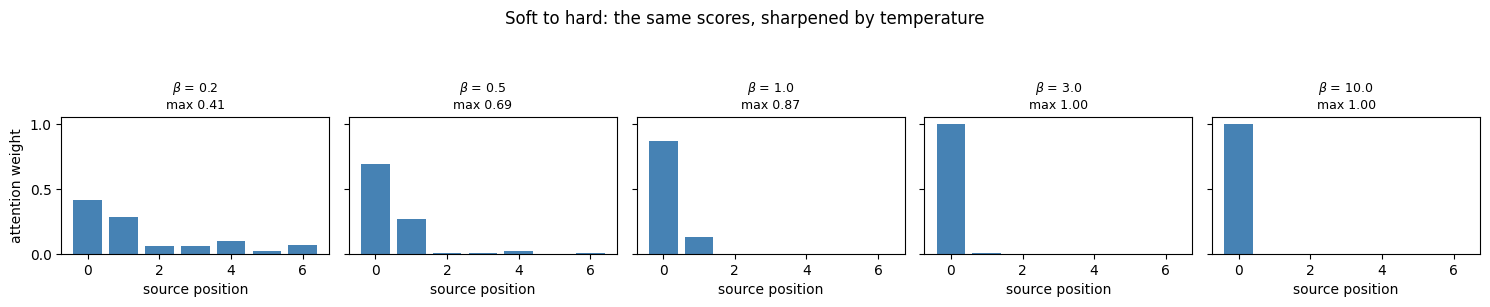

In [11]:
# Static sweep: temperature turns soft attention into hard attention.
fig, ax = plt.subplots(1, 5, figsize=(15, 2.8), sharey=True)
raw = H @ s_prev
for a_, beta in zip(ax, [0.2, 0.5, 1.0, 3.0, 10.0]):
    w = torch.softmax(beta * raw, dim=0)
    a_.bar(range(T), w.numpy(), color='steelblue')
    a_.set_title(f'$\\beta$ = {beta}\nmax {w.max():.2f}', fontsize=9)
    a_.set_xlabel('source position')
ax[0].set_ylabel('attention weight')
fig.suptitle('Soft to hard: the same scores, sharpened by temperature', y=1.08)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [12]:
# Live: compare score functions and sharpness on the same encoder states.
from ipywidgets import interact, FloatSlider, Dropdown

def show(score='dot', beta=1.0):
    fn = {'dot': score_dot, 'scaled': score_scaled, 'general': score_general,
          'cosine': score_cosine, 'additive': score_additive}[score]
    w = torch.softmax(beta * fn(s_prev, H), dim=0)
    ent = -(w * w.log()).sum()
    fig, a_ = plt.subplots(figsize=(7, 3))
    a_.bar(range(T), w.detach().numpy(), color='steelblue')
    a_.set_xlabel('source position'); a_.set_ylabel('attention weight')
    a_.set_title(f'{score} attention, $\\beta$={beta:.1f}   entropy {ent:.2f} nats   max {w.max():.2f}')
    plt.tight_layout(); plt.show()

interact(show, score=Dropdown(options=['dot', 'scaled', 'general', 'cosine', 'additive'], value='dot'),
               beta=FloatSlider(min=0.1, max=10, step=0.1, value=1.0));

interactive(children=(Dropdown(description='score', options=('dot', 'scaled', 'general', 'cosine', 'additive')…

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **The bottleneck** | One fixed-length context vector has finite capacity; long inputs degrade, and BLEU falls rather than saturating |
| **Attention** | $c_t = \sum_j \alpha_{t,j} h_j$ — a fresh context vector at every decoder step, built from *all* encoder states |
| **The weights** | $\alpha_t$ is a softmax over source positions, so it is non-negative and sums to 1 |
| **Score functions** | Dot-product is general with $W_a = I$; cosine is dot-product on normalised vectors; scaling changes temperature, not argmax |
| **Cost** | Dot-product attention is free; general costs $d^2$; additive costs $2dk + k$ |
| **Space-steps** | An $m \times n \times c$ CNN volume unrolls to $mn$ annotation vectors of length $c$; the FC vector has no spatial structure left |
| **Hard vs soft** | Hard picks one position (stochastic, non-differentiable); soft weights all positions (deterministic, differentiable) |
| **Byproduct** | The weights are directly viewable, which is why attention is often shown as an explanation |

## Exercises

1. **The homework from the slides.** What is the connection between an autoencoder and Principal Component Analysis? Build a linear undercomplete autoencoder with MSE loss on standardised data, and compare its learned subspace against `sklearn.decomposition.PCA`.
2. **Entropy as a diagnostic.** Uniform attention over $T$ positions has entropy $\log T$. Plot attention entropy against decoder step for a run of your choice, and say what a sudden drop would mean.
3. **When does scaling matter?** Scaled dot-product divides by $\sqrt{n}$. Generate scores for growing $d$ and show what happens to the softmax without the scaling. What goes wrong first — the weights or their gradients?
4. **Local attention.** Restrict attention to a window of width $w$ around the highest-scoring position and renormalise. At what $w$ does the output stop changing, and what does that tell you about how peaked the distribution was?
5. **Attention as explanation.** The slides present the weights as a byproduct that explains the model. Construct two different weight vectors that give the *same* context vector, and use them to argue about the limits of that claim.
